In [3]:
import os
os.chdir("..")
print("Working dir:", os.getcwd())

Working dir: /Users/mohammadabdulmuneermognishaik/Documents/Projects/stock-market-data-pipeline


In [4]:
from pathlib import Path

In [5]:
import sqlite3

conn = sqlite3.connect("/Users/mohammadabdulmuneermognishaik/Documents/Projects/stock-market-data-pipeline/database/stock.db")
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

print(tables)

conn.close()

[('stock_prices',)]


In [6]:
import sqlite3
import pandas as pd
conn = sqlite3.connect("/Users/mohammadabdulmuneermognishaik/Documents/Projects/stock-market-data-pipeline/database/stock.db")
df = pd.read_sql("SELECT * FROM stock_prices;", conn)
print(df)
conn.close()

          Price               Close                High                 Low  \
0        Ticker                MSFT                MSFT                MSFT   
1          Date                 NaN                 NaN                 NaN   
2    2024-04-25   393.0078430175781   393.8449998393028  382.16426819567243   
3    2024-04-26   400.1778259277344   406.7568397543272   399.6262936342629   
4    2024-04-29   396.1693115234375  400.17779380940664   393.1555709987601   
..          ...                 ...                 ...                 ...   
498  2026-04-20  418.07000732421875   423.3299865722656  416.29998779296875   
499  2026-04-21   424.1600036621094  427.17999267578125  417.20001220703125   
500  2026-04-22   432.9200134277344  433.70001220703125   423.6700134277344   
501  2026-04-23              415.75   423.6600036621094   411.4100036621094   
502  2026-04-24   424.6199951171875  424.95001220703125  415.79998779296875   

                   Open    Volume  
0              

In [7]:
# Clean dataset 
df.head(10)

,Price,Close,High,Low,Open,Volume
0,Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
1,Date,NaN,NaN,NaN,NaN,NaN
2,2024-04-25,393.0078430175781,393.8449998393028,382.16426819567243,388.0735680343126,40586500
3,2024-04-26,400.1778259277344,406.7568397543272,399.6262936342629,405.93939976601416,29694700
4,2024-04-29,396.1693115234375,400.17779380940664,393.1555709987601,399.12396145400385,19582100
5,2024-04-30,383.444580078125,396.0806489273893,383.28702520862055,395.42076392930267,28781400
6,2024-05-01,388.9698181152344,395.6473257764034,384.4098035661703,386.6750231640028,23562500
7,2024-05-02,391.82598876953125,393.88439136644655,388.6842084752251,391.6487169798458,17709400
8,2024-05-03,400.51263427734375,400.99521746175435,395.7851765465019,396.1988407447482,17446700
9,2024-05-06,407.2886962890625,407.67278519206855,400.2270689712312,402.5809547625938,16996600


In [8]:
df = df[df['Price'] != 'Ticker']
df = df[df['Price'] != 'Date']
df = df.rename(columns={'Price': 'Date'})
# Remove nulls
df = df.dropna()
df.head()

,Date,Close,High,Low,Open,Volume
2,2024-04-25,393.0078430175781,393.8449998393028,382.16426819567243,388.0735680343126,40586500
3,2024-04-26,400.1778259277344,406.7568397543272,399.6262936342629,405.93939976601416,29694700
4,2024-04-29,396.1693115234375,400.17779380940664,393.1555709987601,399.12396145400385,19582100
5,2024-04-30,383.444580078125,396.0806489273893,383.28702520862055,395.42076392930267,28781400
6,2024-05-01,388.9698181152344,395.6473257764034,384.4098035661703,386.6750231640028,23562500


In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df['Close'] = pd.to_numeric(df['Close'])
df['Open'] = pd.to_numeric(df['Open'])
df['High'] = pd.to_numeric(df['High'])
df['Low'] = pd.to_numeric(df['Low'])
df['Volume'] = pd.to_numeric(df['Volume'])
print(df.head())
print(df.dtypes)

        Date       Close        High         Low        Open    Volume
2 2024-04-25  393.007843  393.845000  382.164268  388.073568  40586500
3 2024-04-26  400.177826  406.756840  399.626294  405.939400  29694700
4 2024-04-29  396.169312  400.177794  393.155571  399.123961  19582100
5 2024-04-30  383.444580  396.080649  383.287025  395.420764  28781400
6 2024-05-01  388.969818  395.647326  384.409804  386.675023  23562500
Date      datetime64[us]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object


# Analysis
1. Is price going up or down?
2. How fast does it move?
3. Is it stable or crazy?

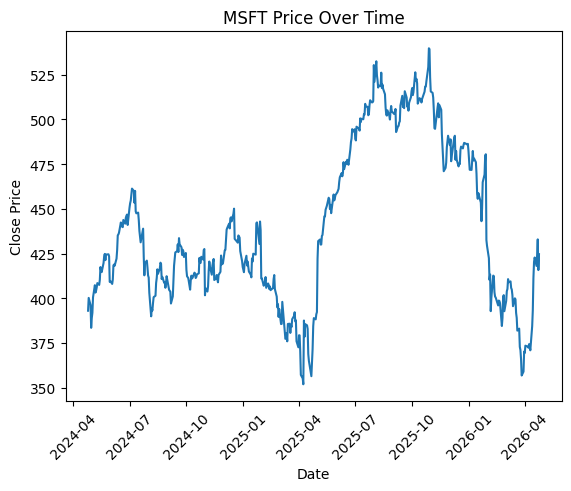

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df['Date'], df['Close'])
plt.title("MSFT Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.show()

In [11]:
df.head(10)

,Date,Close,High,Low,Open,Volume
2,2024-04-25,393.007843,393.845000,382.164268,388.073568,40586500
3,2024-04-26,400.177826,406.756840,399.626294,405.939400,29694700
4,2024-04-29,396.169312,400.177794,393.155571,399.123961,19582100
5,2024-04-30,383.444580,396.080649,383.287025,395.420764,28781400
6,2024-05-01,388.969818,395.647326,384.409804,386.675023,23562500
7,2024-05-02,391.825989,393.884391,388.684208,391.648717,17709400
8,2024-05-03,400.512634,400.995217,395.785177,396.198841,17446700
9,2024-05-06,407.288696,407.672785,400.227069,402.580955,16996600
10,2024-05-07,403.152161,408.401606,402.905940,408.391747,20018200
11,2024-05-08,404.334015,405.998470,400.561895,401.999846,11792300


# We did a mean to understand price change overall 

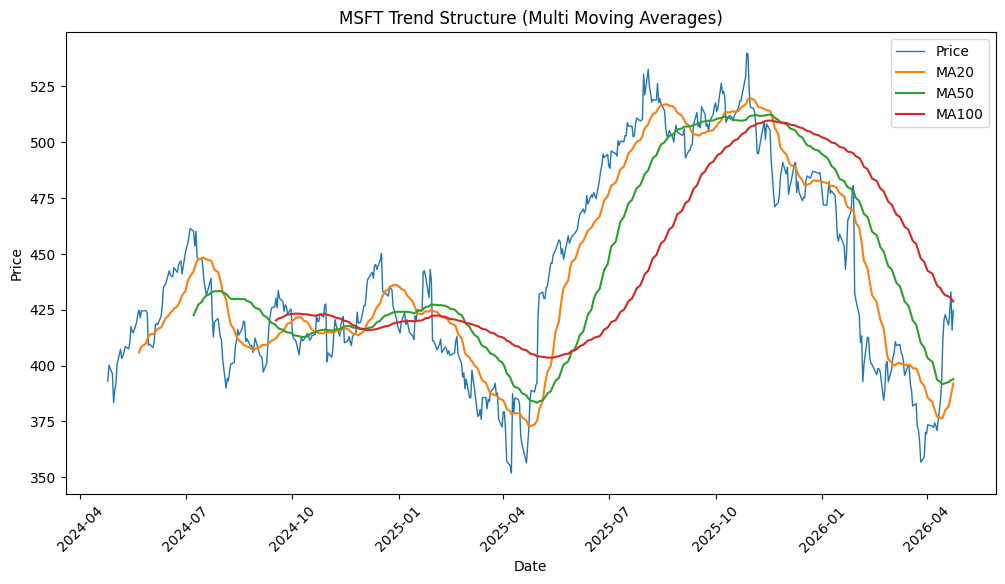

In [12]:
import matplotlib.pyplot as plt

# Ensure data is sorted by date
df = df.sort_values('Date')

# Moving Averages
df['MA_20'] = df['Close'].rolling(20).mean()
df['MA_50'] = df['Close'].rolling(50).mean()
df['MA_100'] = df['Close'].rolling(100).mean()

# Plot
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'], label="Price", linewidth=1)
plt.plot(df['Date'], df['MA_20'], label="MA20")
plt.plot(df['Date'], df['MA_50'], label="MA50")
plt.plot(df['Date'], df['MA_100'], label="MA100")

plt.title("MSFT Trend Structure (Multi Moving Averages)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [28]:
df.head()

,Date,Close,High,Low,Open,Volume,MA_20,MA_50,MA_100,Trend,Momentum,Returns,Volatility,Signal
2,2024-04-25,393.007843,393.845000,382.164268,388.073568,40586500,NaN,NaN,NaN,False,NaN,NaN,NaN,0
3,2024-04-26,400.177826,406.756840,399.626294,405.939400,29694700,NaN,NaN,NaN,False,NaN,0.018244,NaN,0
4,2024-04-29,396.169312,400.177794,393.155571,399.123961,19582100,NaN,NaN,NaN,False,NaN,-0.010017,NaN,0
5,2024-04-30,383.444580,396.080649,383.287025,395.420764,28781400,NaN,NaN,NaN,False,NaN,-0.032119,NaN,0
6,2024-05-01,388.969818,395.647326,384.409804,386.675023,23562500,NaN,NaN,NaN,False,NaN,0.014409,NaN,0


# STEP 1: TREND, MOMENTUM, VOLATILITY, SIGNAL DETECTION (MOST IMPORTANT NEXT STEP)

In [35]:
df['Trend'] = df['MA_20'] > df['MA_100']

In [36]:
# 📊 STEP 2: MOMENTUM (STRENGTH OF MOVE)
df['Momentum'] = df['Close'] - df['Close'].shift(5)

In [37]:
df['Returns'] = df['Close'].pct_change()

In [39]:
# ⚠️ STEP 3: VOLATILITY (RISK LEVEL)
df['Volatility'] = df['Returns'].rolling(20).std()

In [40]:
df['Signal'] = (df['MA_20'] > df['MA_50']).astype(int)

# Visualization

📊 1. PRICE + TREND (MAIN VIEW)

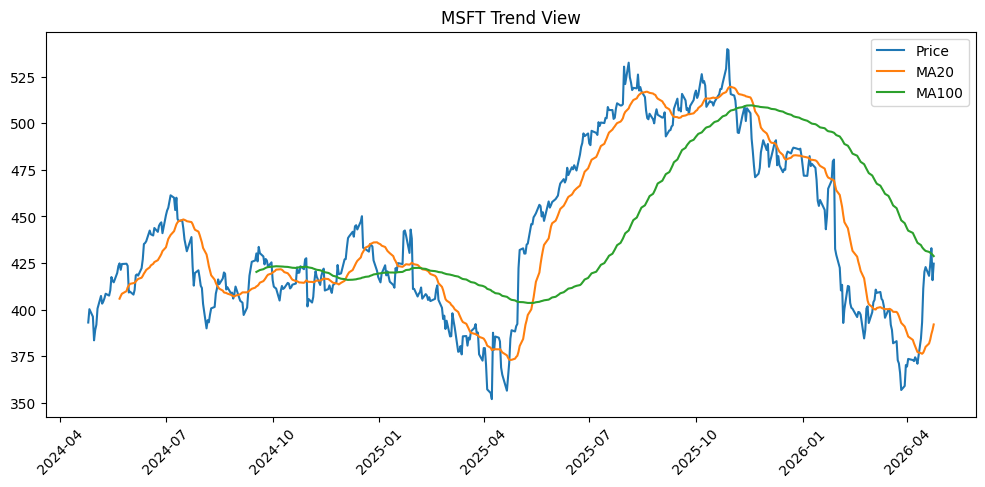

In [41]:
import matplotlib.pyplot as plt

df = df.sort_values('Date')

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], label="Price")
plt.plot(df['Date'], df['MA_20'], label="MA20")
plt.plot(df['Date'], df['MA_100'], label="MA100")

plt.title("MSFT Trend View")
plt.legend()
plt.xticks(rotation=45)
plt.show()

# ⚡ 2. MOMENTUM (STRENGTH)

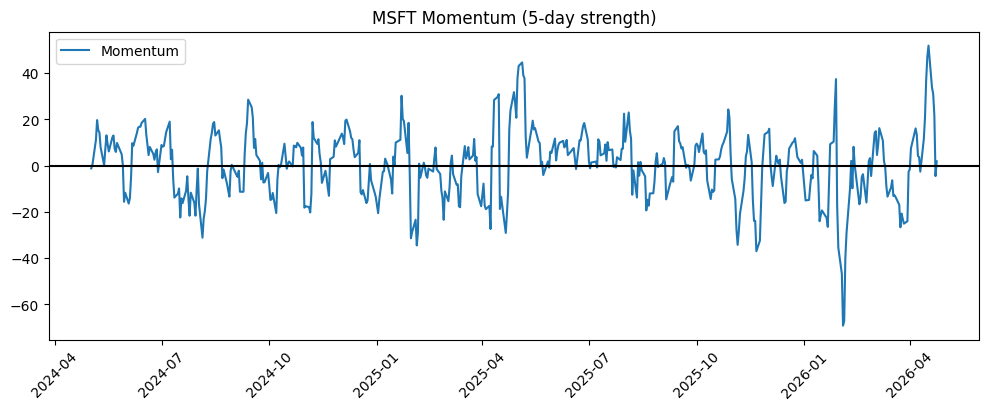

In [42]:
plt.figure(figsize=(12,4))
plt.plot(df['Date'], df['Momentum'], label="Momentum")
plt.axhline(0, color='black')

plt.title("MSFT Momentum (5-day strength)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

# ⚠️ 3. VOLATILITY (RISK)

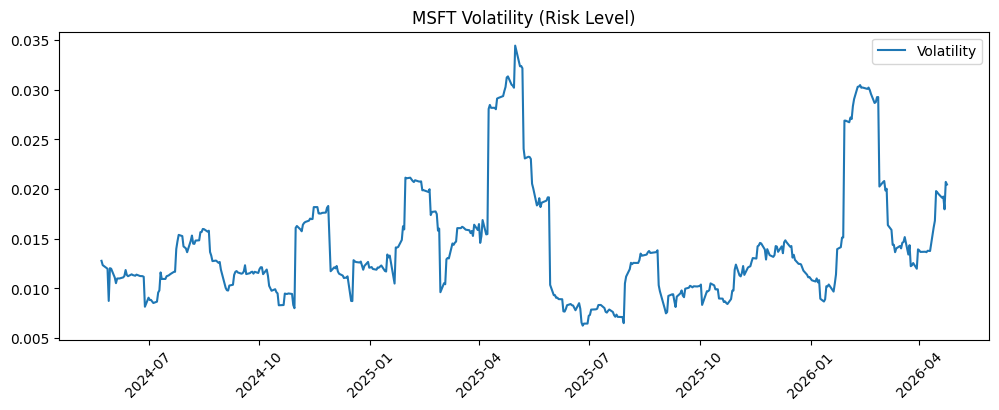

In [43]:
plt.figure(figsize=(12,4))
plt.plot(df['Date'], df['Volatility'], label="Volatility")

plt.title("MSFT Volatility (Risk Level)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [44]:
df = df.sort_values('Date')

df['MA_20'] = df['Close'].rolling(20).mean()
df['MA_50'] = df['Close'].rolling(50).mean()
df['MA_100'] = df['Close'].rolling(100).mean()

df['Returns'] = df['Close'].pct_change()
df['Volatility'] = df['Returns'].rolling(20).std()

df = df.dropna()

In [46]:
df.to_csv("/Users/mohammadabdulmuneermognishaik/Documents/Projects/stock-market-data-pipeline/PowerBI/msft_clean_dashboard.csv", index=False)